in every H3 hexagon of resolution 5, various factors are summarized

In [ ]:
# 1. get the socio-economic data, environmental data, infrastructure data
# 2. generate the H3 hexagons for Arctic Base with resolution 5
# 3. intersect the layer from 1 with 2.
# 4. Summarize within those values within the hexagon so every hexagon will have n number of attributes coming from Step 1


Once layer is ready, implement Mini Som.

In [ ]:
import numpy as np
!pip install minisom
from minisom import MiniSom
from scipy.spatial.distance import cdist


  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.3-py3-none-any.whl size=11706 sha256=ef862f6affa524e55a18794b5ea91a2690d4bab7ab4482abf8e5c3071576fca8
  Stored in directory: /root/.cache/pip/wheels/c8/29/ba/ee521d9a6af783a1e1efb1831fe4afdf526613849b3f58175b
Successfully built minisom


1. Add Spatial Weights to the Training Process
Modify the way nodes compete during training by incorporating spatial proximity between data points.

Use a spatial weight matrix (e.g., inverse distance weighting or adjacency-based weights).
Penalize updates based on geographic distance so that closer points influence each other more.

In [ ]:
# Generate synthetic spatial coordinates (e.g., lat/lon)
num_samples = 100
coords = np.random.rand(num_samples, 2)  # Replace with real geospatial data

# Normalize spatial coordinates
coords = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0))

# Initialize SOM
som_size = (10, 10)
som = MiniSom(som_size[0], som_size[1], input_len=2, sigma=1.0, learning_rate=0.5)

# Train with spatial weights
for data in coords:
    winner = som.winner(data)
    winner_coords = np.array(winner) / np.array(som_size)  # Normalize SOM positions
    dist = cdist([data], [winner_coords], metric='euclidean')  # Distance penalty
    weight = np.exp(-dist)  # Spatial weight function (e.g., Gaussian decay)
    som.update(data * weight, winner, 0.5, 1.0)  # Apply spatial influence


 Effect: This ensures that closer points in real space have more influence on their BMUs (Best Matching Units) than distant ones.

2. Constrain SOM Grid to Geographic Space
Instead of the standard rectangular SOM grid, align the nodes with real-world coordinates. You can use a spatially distributed hexagonal or regular grid.

Steps:

Define a grid of SOM neurons that matches a real-world projection (e.g., a regular grid overlaid on a map).
Adjust BMU selection by considering spatial proximity in addition to feature similarity.

<Axes: >

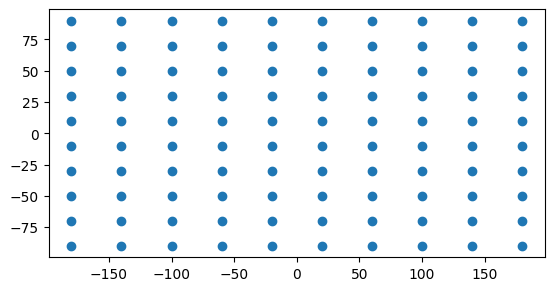

In [ ]:
# Example: Create a geographic SOM grid
import geopandas as gpd
from shapely.geometry import Point

# Define a SOM grid over a region (e.g., latitude/longitude)
grid_size = 10  # 10x10 grid
min_x, max_x = -180, 180
min_y, max_y = -90, 90

# Generate a regular spatial grid
x_coords = np.linspace(min_x, max_x, grid_size)
y_coords = np.linspace(min_y, max_y, grid_size)
grid_points = [Point(x, y) for x in x_coords for y in y_coords]

# Store as GeoDataFrame
som_grid = gpd.GeoDataFrame(geometry=grid_points, crs="EPSG:4326")
som_grid.plot()


Effect: Each SOM node now represents a real-world location instead of an abstract unit.

In [ ]:
!pip install h3